# Titanic: Práce s daty

Kompletní pipeline datové analýzy a strojového učení na datasetu z katastrofy lodi Titanic.

Části:
1. Průzkumová analýza dat
2. Předzpracování dat
3. Klasifikační modely (Decision Tree, Random Forest, Neural Network, AdaBoost)

In [61]:
!pip install numpy pandas matplotlib seaborn scikit-learn torch

In [62]:
import os

os.makedirs('results', exist_ok=True)

---

# Titanic: Průzkumová analýza dat (EDA)

**EDA** (Exploratory Data Analysis) je proces vizuálního a statistického zkoumání datasetu.
Cílem je pochopit strukturu dat, odhalit chybějící hodnoty, identifikovat vzory
a vztahy mezi proměnnými a vybrat vhodný přístup pro předzpracování a modelování.

Dataset pochází z katastrofy lodi [Titanic](https://www.kaggle.com/c/titanic).
Na základě informací o pasažérech budeme predikovat, zda přežili nebo nepřežili.

In [63]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Načtení dat

In [64]:
train = pd.read_csv('../data/train.csv')
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### Popis sloupců

| Sloupec | Popis |
|---------|-------|
| **PassengerId** | Unikátní ID pasažéra |
| **Survived** | 0 = Nepřežil, 1 = Přežil |
| **Pclass** | Třída cestovního lístku (1 = 1., 2 = 2., 3 = 3.) |
| **Name** | Jméno pasažéra |
| **Sex** | Pohlaví (male, female) |
| **Age** | Věk v letech |
| **SibSp** | Počet sourozenců / manželů/manželek na palubě |
| **Parch** | Počet rodičů / dětí na palubě |
| **Ticket** | Číslo lístku |
| **Fare** | Cena jízdenky |
| **Cabin** | Číslo kajuty |
| **Embarked** | Přístav nalodění (C = Cherbourg, Q = Queenstown, S = Southampton) |

Zdroj: [Kaggle](https://www.kaggle.com/c/titanic/data)

## Vizualizace

### Distribuce cílové proměnné

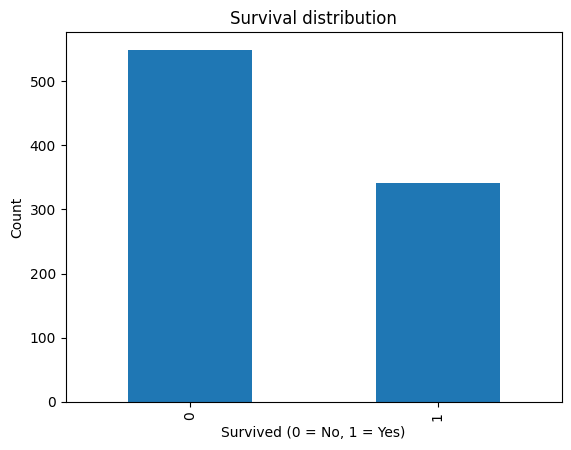

In [65]:
train['Survived'].value_counts().plot(kind='bar')
plt.title('Survival distribution')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

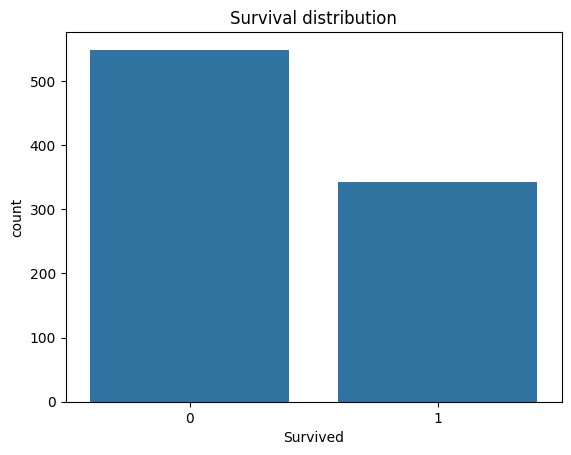

In [66]:
# Same using seaborn
sns.countplot(x='Survived', data=train)
plt.title('Survival distribution')
plt.show()

### Přežití podle třídy

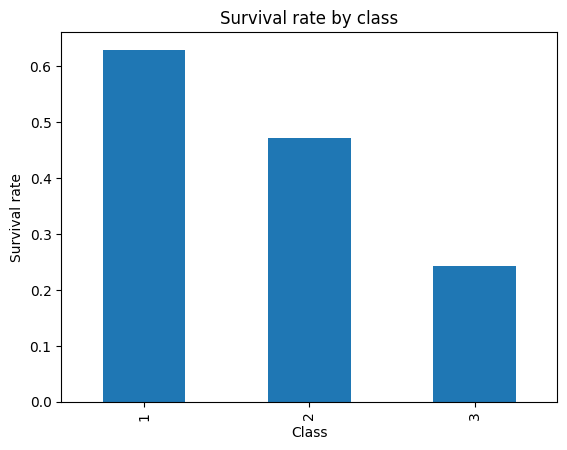

In [67]:
train.groupby('Pclass')['Survived'].mean().plot(kind='bar')
plt.title('Survival rate by class')
plt.xlabel('Class')
plt.ylabel('Survival rate')
plt.show()

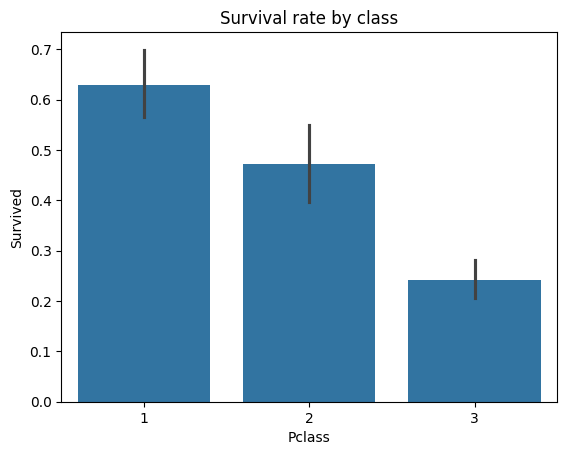

In [68]:
sns.barplot(x='Pclass', y='Survived', data=train)
plt.title('Survival rate by class')
plt.show()

### Přežití podle pohlaví

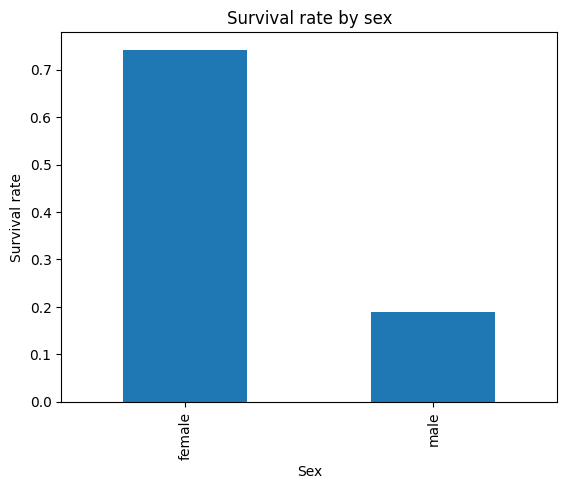

In [69]:
train.groupby('Sex')['Survived'].mean().plot(kind='bar')
plt.title('Survival rate by sex')
plt.xlabel('Sex')
plt.ylabel('Survival rate')
plt.show()

### Distribuce věku podle přežití

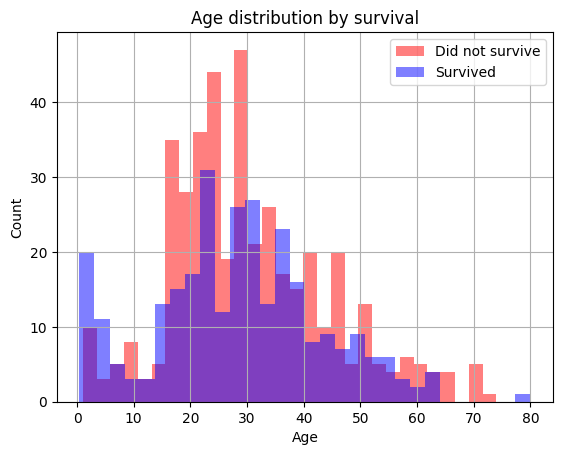

In [70]:
train[train['Survived'] == 0]['Age'].hist(bins=30, alpha=0.5, color='red', label='Did not survive')
train[train['Survived'] == 1]['Age'].hist(bins=30, alpha=0.5, color='blue', label='Survived')
plt.title('Age distribution by survival')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()

### Přežití podle počtu sourozenců/partnerů (SibSp)

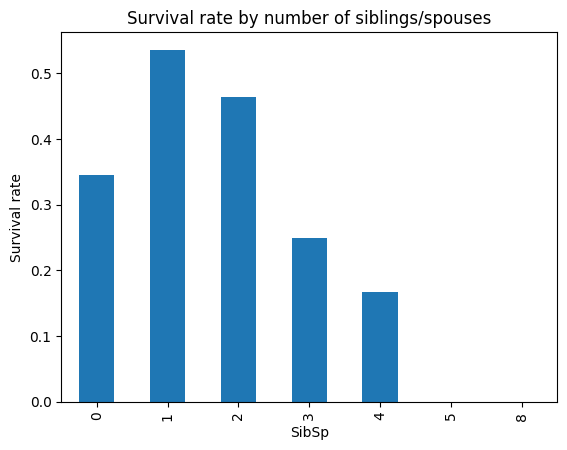

In [71]:
train.groupby('SibSp')['Survived'].mean().plot(kind='bar')
plt.title('Survival rate by number of siblings/spouses')
plt.xlabel('SibSp')
plt.ylabel('Survival rate')
plt.show()

### Přežití podle počtu rodičů/dětí (Parch)

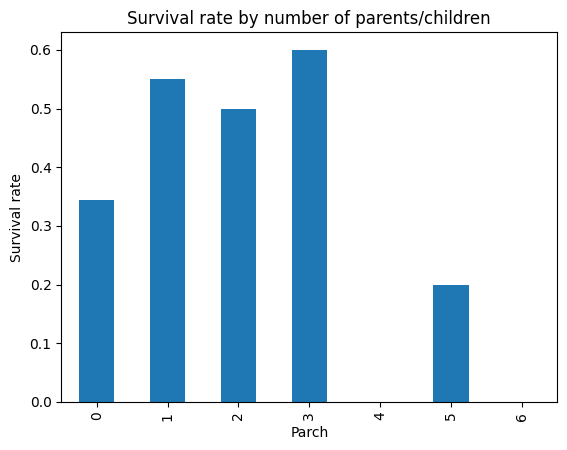

In [72]:
train.groupby('Parch')['Survived'].mean().plot(kind='bar')
plt.title('Survival rate by number of parents/children')
plt.xlabel('Parch')
plt.ylabel('Survival rate')
plt.show()

### Distribuce ceny jízdenky podle přežití

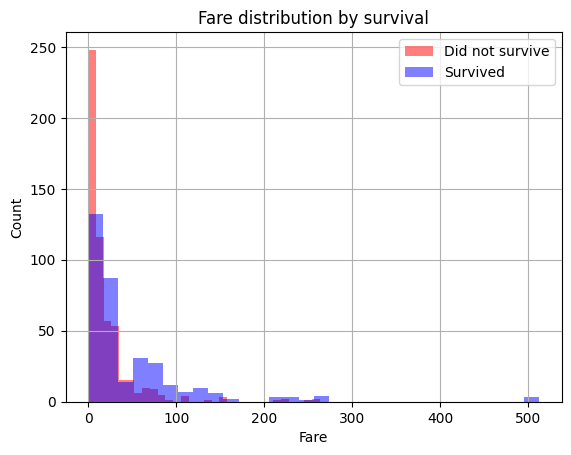

In [73]:
train[train['Survived'] == 0]['Fare'].hist(bins=30, alpha=0.5, color='red', label='Did not survive')
train[train['Survived'] == 1]['Fare'].hist(bins=30, alpha=0.5, color='blue', label='Survived')
plt.title('Fare distribution by survival')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.legend()
plt.show()

### Kajuta a přežití

In [74]:
train['Cabin'].isna().sum()

np.int64(687)

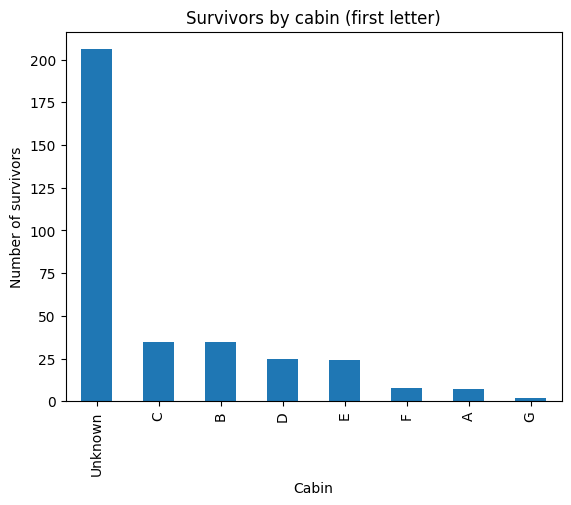

In [75]:
train[train['Survived'] == 1]['Cabin'].str[0].fillna('Unknown').value_counts().plot(kind='bar')
plt.title('Survivors by cabin (first letter)')
plt.xlabel('Cabin')
plt.ylabel('Number of survivors')
plt.show()

### Přežití podle přístavu nalodění

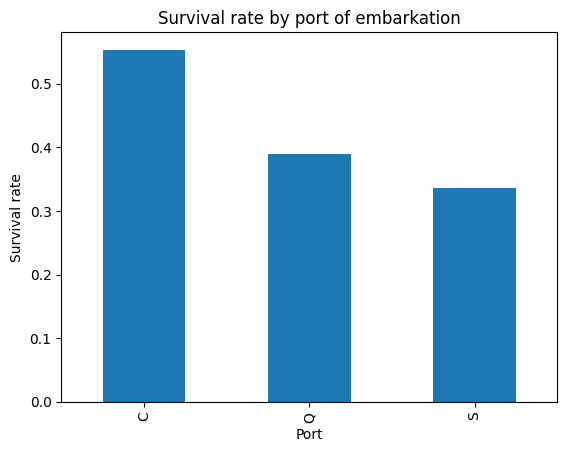

In [76]:
train.groupby('Embarked')['Survived'].mean().plot(kind='bar')
plt.title('Survival rate by port of embarkation')
plt.xlabel('Port')
plt.ylabel('Survival rate')
plt.show()

---

# Titanic: Předzpracování dat

Než začneme trénovat modely, musíme data připravit — odstranit nepotřebné sloupce,
zpracovat chybějící hodnoty a zakódovat kategorické proměnné.

## Rozdělení na trénovací a testovací data

- **Trénovací data (train)** — na těchto datech model trénujeme, známe správné odpovědi
- **Testovací data (test)** — na těchto datech model vyhodnocujeme, neznáme správné odpovědi

![Train-Test split](../img/train-test-split.jpg)

Zdroj: [builtin.com](https://builtin.com/data-science/train-test-split)

In [77]:
# Reload data (clean copy)
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

len(train), len(test)

(891, 418)

## Odstranění nepotřebných sloupců

In [78]:
# From the training data, drop PassengerId, Name, Ticket, Cabin
train = train.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# From the test data, keep PassengerId (needed for submission)
test = test.drop(columns=['Name', 'Ticket', 'Cabin'])

train

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


## Zpracování chybějících hodnot

In [79]:
# Which columns have missing values?
print("Training data:")
print(train.isnull().sum())
print()
print("Test data:")
print(test.isnull().sum())

Training data:
Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

Test data:
PassengerId     0
Pclass          0
Sex             0
Age            86
SibSp           0
Parch           0
Fare            1
Embarked        0
dtype: int64


Chybějící hodnoty můžeme:
- **odstranit** — smazat řádky s chybějícími hodnotami
- **doplnit** — nahradit průměrem (mean), mediánem (median) nebo nejčastější hodnotou (mode)

In [80]:
train['Age'].mean()

np.float64(29.69911764705882)

In [81]:
# mode() returns a Series with the most frequent value
train['Embarked'].mode()

0    S
Name: Embarked, dtype: str

In [82]:
# Fill missing values in training data
train['Age'] = train['Age'].fillna(train['Age'].mean())
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])

# Fill missing values in test data
test['Age'] = test['Age'].fillna(test['Age'].mean())
test['Fare'] = test['Fare'].fillna(test['Fare'].mean())

In [83]:
# Verify — no missing values
print("Training data:")
print(train.isnull().sum())
print()
print("Test data:")
print(test.isnull().sum())

Training data:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Test data:
PassengerId    0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64


## Kódování kategorických proměnných

Modely strojového učení vyžadují numerický vstup.
Kategorické sloupce musíme převést na čísla.

In [84]:
# Which columns are categorical?
train.dtypes

Survived      int64
Pclass        int64
Sex             str
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked        str
dtype: object

Použijeme **one-hot encoding** — pro každou kategorii vytvoříme nový binární sloupec.

In [85]:
train = pd.get_dummies(train, columns=["Sex", "Embarked"])
test = pd.get_dummies(test, columns=["Sex", "Embarked"])

train

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.000000,1,0,7.2500,False,True,False,False,True
1,1,1,38.000000,1,0,71.2833,True,False,True,False,False
2,1,3,26.000000,0,0,7.9250,True,False,False,False,True
3,1,1,35.000000,1,0,53.1000,True,False,False,False,True
4,0,3,35.000000,0,0,8.0500,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000,False,True,False,False,True
887,1,1,19.000000,0,0,30.0000,True,False,False,False,True
888,0,3,29.699118,1,2,23.4500,True,False,False,False,True
889,1,1,26.000000,0,0,30.0000,False,True,True,False,False


---

# Titanic: Klasifikační modely

![Typy klasifikačních modelů](../img/classification-model-types.jpg)

Zdroj: [datacamp.com](https://www.datacamp.com/tutorial/adaboost-classifier-python)

## Příprava dat pro trénování

In [86]:
X = train.drop(columns='Survived')
y = train['Survived']

print(f"Number of features: {X.shape[1]}")
print(f"Features: {list(X.columns)}")

Number of features: 10
Features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S']


## Náhodný klasifikátor (Random Classifier)

Baseline — model, který predikuje náhodně. Očekávaná přesnost ~50 %.

In [87]:
submission_random = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': np.random.randint(0, 2, size=len(test))
})

submission_random.head()

,PassengerId,Survived
0,892,1
1,893,0
2,894,0
3,895,0
4,896,1


In [88]:
submission_random.to_csv('results/submission_random.csv', index=False)

## Rozhodovací strom (Decision Tree)

Rozhodovací strom postupně rozděluje data podmínkami typu `feature <= hodnota`.
Každá podmínka tvoří větev stromu, na konci (v **listech**) jsou finální predikce.

### Jak strom vybírá rozdělení?

Strom prochází všechny sloupce a pro každý zkouší různé dělící hodnoty.
Pro každé dělení spočítá **Gini index** (nečistotu uzlu) potomků a vybere
to dělení, které nejvíce sníží nečistotu.

$$\text{Gini}(t) = 1 - \sum_{i=1}^{C} p_i^2$$

kde $p_i$ je podíl vzorků třídy $i$ v uzlu $t$ a $C$ je počet tříd.

- **Gini = 0** — uzel obsahuje jen jednu třídu (čistý)
- **Gini = 0.5** — pro binární klasifikaci maximální nečistota (50 / 50)

**Příklad výpočtu**: v uzlu je 100 pasažérů, z toho 60 přežilo a 40 zahynulo:

$$\text{Gini} = 1 - \left(\frac{60}{100}\right)^2 - \left(\frac{40}{100}\right)^2 = 1 - 0.36 - 0.16 = 0.48$$

### Vážený Gini po rozdělení

Když strom uzel rozdělí na dva potomky, spočítá **vážený Gini** podle počtu vzorků
v každém potomkovi:

$$\text{Gini}_{\text{split}} = \frac{n_L}{n} \cdot \text{Gini}_L + \frac{n_R}{n} \cdot \text{Gini}_R$$

**Příklad**: rozdělíme uzel výše (100 vzorků, 60 přežilo, 40 zahynulo, Gini = 0.48)
podle `Sex_female <= 0.5`:

- levý potomek — muži, 60 vzorků: 20 přežilo, 40 zahynulo
  $$\text{Gini}_L = 1 - (20/60)^2 - (40/60)^2 \approx 0.444$$
- pravý potomek — ženy, 40 vzorků: 40 přežilo, 0 zahynulo
  $$\text{Gini}_R = 1 - (40/40)^2 - 0^2 = 0$$
- vážený Gini:
  $$\text{Gini}_{\text{split}} = \frac{60}{100} \cdot 0.444 + \frac{40}{100} \cdot 0 \approx 0.267$$

Rozdělení snížilo nečistotu z **0.48** na **0.267** — zisk 0.213.
Strom vyzkouší všechny sloupce a dělící hodnoty a vybere to s největším ziskem.

### Parametr `max_depth`

Omezuje hloubku stromu. Vyšší hodnota → model se lépe přizpůsobí trénovacím datům,
ale hrozí **přetrénování** (overfitting) — model se naučí specifika tréninkové sady
a hůř generalizuje na nová data. Hodnota kolem 3–5 bývá dobrý kompromis.

In [89]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

decision_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

decision_tree.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

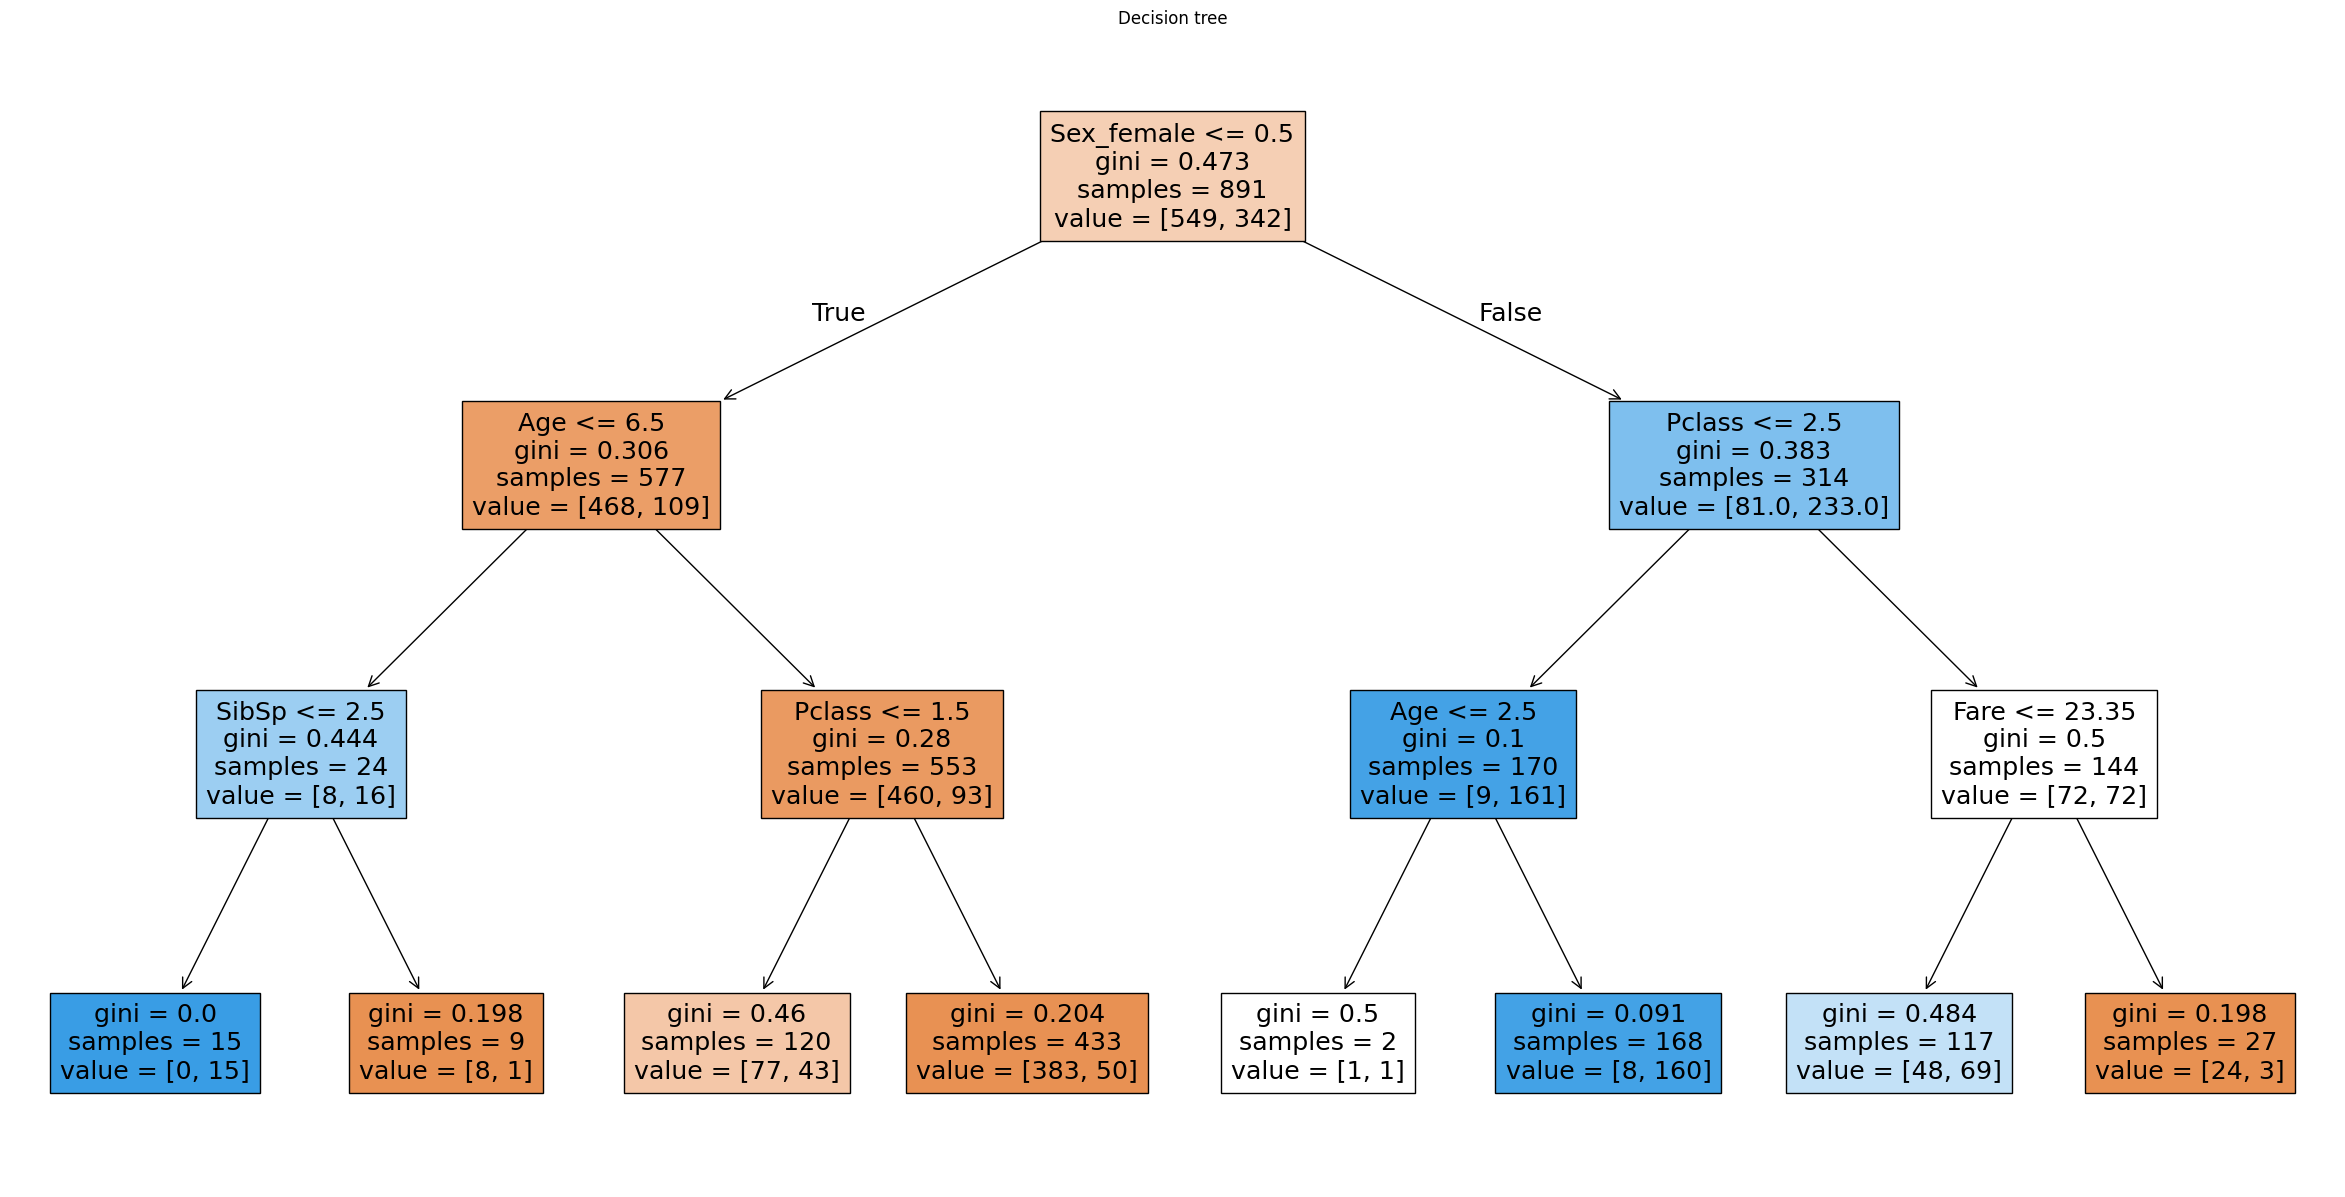

In [90]:
# Visualize the decision tree
plt.figure(figsize=(30, 15))
plot_tree(decision_tree, feature_names=X.columns, filled=True)
plt.title('Decision tree')
plt.show()

### Jak číst vizualizaci stromu

V každém uzlu vidíte tyto informace:

- **`feature <= value`** — dělící podmínka. Vzorky, pro které platí, jdou do **levého** potomka; ostatní do **pravého**
- **`gini`** — Gini index (nečistota) uzlu
- **`samples`** — počet trénovacích vzorků, které do uzlu dorazily
- **`value = [a, b]`** — rozložení tříd: `[počet_nepřeživších, počet_přeživších]`
- **`class`** — predikovaná třída (majoritní třída v uzlu)

**Barva uzlu** odráží majoritní třídu a její čistotu:
- oranžové odstíny = nepřežili, modré odstíny = přežili
- sytější barva = čistější uzel (blíže Gini = 0)
- bílá/světlá = smíšený uzel (Gini blíže 0.5)

**Jak funguje predikce**: nový vzorek začne v kořeni, postupně se rozhoduje
podle podmínek až dojde do listu — třída v listu je predikce.

In [91]:
# Predict on test data
y_pred = decision_tree.predict(test.drop(columns=['PassengerId']))
y_pred[:10]

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0])

In [92]:
submission_decision_tree = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': y_pred
})

submission_decision_tree.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [93]:
submission_decision_tree.to_csv('results/submission_decision_tree.csv', index=False)

## Náhodný les (Random Forest)

Ensemble metoda — kombinuje mnoho rozhodovacích stromů a výslednou predikci
určuje **většinovým hlasováním**.

### Proč funguje lépe než jeden strom?

Jeden hluboký rozhodovací strom snadno přetrénuje — naučí se specifika trénovacích dat
a hůř generalizuje. Random Forest tento problém řeší dvěma triky, které zavádějí
**různorodost** mezi stromy:

1. **Bagging (Bootstrap Aggregating)** — každý strom se trénuje na jiném náhodném
   podvzorku dat vybíraném **s opakováním**. Pro 891 vzorků vybereme 891 vzorků náhodně
   s opakováním — v průměru asi 63 % unikátních, 37 % dat strom nevidí.
2. **Náhodný výběr features** — při hledání nejlepšího rozdělení uzlu se uvažuje
   jen náhodná podmnožina sloupců (typicky $\sqrt{\text{features}}$).

Díky tomu jsou stromy v lese **různorodé** — dělají různé chyby, které se při hlasování
vyruší. Zprůměrování mnoha "průměrných" modelů často překoná jediný "optimální" model.

### Klíčové parametry

- `n_estimators=100` — počet stromů v lese. Více stromů = stabilnější predikce,
  ale delší trénink (diminishing returns nad ~100–500)
- `max_depth=3` — maximální hloubka každého stromu (stejný smysl jako u jednoho stromu)

### Intuice

Místo toho, abychom se zeptali jednoho experta, zeptáme se 100 mírně odlišných expertů
a vezmeme většinový názor. Někteří budou mít pravdu tam, kde se ostatní pletou — a naopak.
Pokud jsou chyby **nezávislé**, průměr je přesnější než kterýkoli jednotlivec.

In [94]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    random_state=42
)

random_forest.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [95]:
y_pred = random_forest.predict(test.drop(columns=['PassengerId']))

submission_random_forest = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': y_pred
})

submission_random_forest.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [96]:
submission_random_forest.to_csv('results/submission_random_forest.csv', index=False)

## Neuronová síť (PyTorch)

Neuronová síť je vrstvený model, který se učí zachytit složité **nelineární**
vztahy mezi vstupy a výstupy. Data protékají sítí přes sérii transformací
(vrstev) a mezi nimi jsou aplikovány nelineární **aktivační funkce**.

### Vrstvy (`nn.Linear`)

Každá plně propojená vrstva provádí lineární transformaci:

$$y = W x + b$$

kde $W$ je **matice vah** a $b$ je **vektor posunů** (bias).
`nn.Linear(32, 64)` znamená vstup dimenze 32, výstup dimenze 64 —
matice $W$ má tvar $64 \times 32$, vektor $b$ má 64 prvků.

V našem modelu máme tři vrstvy:
- `fc1`: 10 → 32 (vstupních 10 features → 32 neuronů)
- `fc2`: 32 → 64
- `fc3`: 64 → 1 (jeden výstup = pravděpodobnost přežití)

Počet parametrů k naučení:
$$(10 \cdot 32 + 32) + (32 \cdot 64 + 64) + (64 \cdot 1 + 1) = 352 + 2112 + 65 = 2529$$

### Aktivační funkce

Mezi vrstvami aplikujeme **nelineární funkci**. Bez ní by celá síť (bez ohledu
na počet vrstev) byla jen jednou lineární transformací.

- **ReLU** (Rectified Linear Unit): $\text{ReLU}(x) = \max(0, x)$ — jednoduchá, rychlá,
  standardní volba pro skryté vrstvy
- **Sigmoid**: $\sigma(x) = \dfrac{1}{1 + e^{-x}}$ — převede libovolné číslo na interval
  $(0, 1)$, vhodné pro binární výstup (pravděpodobnost třídy)

**Příklad**: pro vstup $x = -2$ je $\text{ReLU}(-2) = 0$ a $\sigma(-2) \approx 0.119$.
Pro $x = 2$ je $\text{ReLU}(2) = 2$ a $\sigma(2) \approx 0.881$.

### Loss funkce — BCELoss (Binary Cross-Entropy)

Měří, jak moc se predikce $\hat{y} \in (0, 1)$ liší od správné odpovědi $y \in \{0, 1\}$:

$$\text{BCE} = -[y \log(\hat{y}) + (1-y) \log(1-\hat{y})]$$

- Správná predikce (např. $y=1$, $\hat{y}=0.99$): $-\log(0.99) \approx 0.01$
- Zmatený model (např. $y=1$, $\hat{y}=0.5$): $-\log(0.5) \approx 0.693$
- Sebevědomá chyba (např. $y=1$, $\hat{y}=0.01$): $-\log(0.01) \approx 4.605$

**Čím menší loss, tím lepší predikce.**

### Optimizér — Adam

Optimizér upravuje váhy $W$ a posuny $b$ tak, aby se loss zmenšila.
Používá **gradientní sestup** — spočítá, jak by se loss změnila při malé změně
každé váhy, a posune váhy opačným směrem.

**Adam** je adaptivní varianta: pamatuje si historii gradientů a pro každou váhu
samostatně upravuje velikost kroku. Funguje dobře bez ladění.

Parametr `lr=0.001` (learning rate) určuje základní velikost kroku:
- příliš velký → skáčeme přes minimum, loss osciluje
- příliš malý → učení je pomalé nebo uvízne

### Epochy a batche

- **Epoch** — jeden průchod **všemi** trénovacími daty
- **Batch** — malý podvzorek dat (`batch_size=32`), na kterém se spočítá gradient
  a zaktualizují váhy
- **Iterace** — jeden krok optimizéru (= jeden batch)

Trénujeme 1000 epoch, v každé je $\lceil 891 / 32 \rceil = 28$ iterací —
celkem **28 000 aktualizací vah**.

**Proč batche?** Trénink po celém datasetu najednou by byl pomalý a paměťově náročný.
Trénink po jednom vzorku by byl nestabilní. Batch je kompromis — rychlejší,
ale stále stabilní gradienty.

In [97]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [98]:
# Convert to PyTorch tensors
X_tensor = torch.tensor(X.astype('float32').values)
y_tensor = torch.tensor(y.values).reshape(-1, 1).float()

print(f"X shape: {X_tensor.shape}")
print(f"y shape: {y_tensor.shape}")

X shape: torch.Size([891, 10])
y shape: torch.Size([891, 1])


In [99]:
# Define the neural network
class NeuralNetwork(nn.Module):
    def __init__(self, input_size=10):
        super(NeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.fc2 = nn.Linear(32, 64)
        self.fc3 = nn.Linear(64, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x

In [100]:
# Create the model
model = NeuralNetwork(input_size=X_tensor.shape[1])

# Loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [101]:
# DataLoader
dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [102]:
import copy

# Training
best_model = None
best_loss = float('inf')

for epoch in range(1000):
    for X_batch, y_batch in dataloader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

    if loss.item() < best_loss:
        best_loss = loss.item()
        best_model = copy.deepcopy(model.state_dict())

    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch + 1}/1000, Loss: {loss.item():.4f}')

print(f'\nBest loss: {best_loss:.4f}')

Epoch 100/1000, Loss: 0.4799
Epoch 200/1000, Loss: 0.5275
Epoch 300/1000, Loss: 0.2740
Epoch 400/1000, Loss: 0.4385
Epoch 500/1000, Loss: 0.5377
Epoch 600/1000, Loss: 0.4398
Epoch 700/1000, Loss: 0.1717
Epoch 800/1000, Loss: 0.1502
Epoch 900/1000, Loss: 0.1997
Epoch 1000/1000, Loss: 0.2348

Best loss: 0.0676


In [103]:
# Predict on test data
model.load_state_dict(best_model)

test_X_tensor = torch.tensor(
    test.drop(columns='PassengerId').astype('float32').values
)

y_pred = model(test_X_tensor)
y_pred = (y_pred > 0.5).float()
y_pred = y_pred.detach().numpy().reshape(-1)

submission_neural_network = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': y_pred.astype(int)
})

submission_neural_network.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [104]:
submission_neural_network.to_csv('results/submission_neural_network.csv', index=False)

---

# Pokročilé modely (Bonus)

## AdaBoost

**Adaptive Boosting** — ensemble metoda, která postupně trénuje **slabé klasifikátory**
(typicky mělké rozhodovací stromy) a kombinuje je do jednoho silného modelu.

Na rozdíl od Random Forest, kde se stromy trénují **nezávisle paralelně**,
AdaBoost trénuje stromy **sekvenčně** — každý další se učí z chyb předchůdců.

### Algoritmus

1. Každému trénovacímu vzorku přiřaď stejnou váhu: $w_i = 1/N$
2. Pro $t = 1, 2, \dots, T$:
   - Natrénuj slabý klasifikátor $h_t$ na datech s vahami $w_i$
   - Spočítej jeho **váženou chybu**:
     $$\varepsilon_t = \sum_{i : h_t(x_i) \ne y_i} w_i$$
   - Spočítej **váhu klasifikátoru**:
     $$\alpha_t = \frac{1}{2} \ln\left(\frac{1 - \varepsilon_t}{\varepsilon_t}\right)$$
   - **Zvyš váhy špatně klasifikovaným** vzorkům, sniž váhy správně klasifikovaným:
     $$w_i \leftarrow w_i \cdot e^{\alpha_t \cdot \mathbb{1}[h_t(x_i) \ne y_i]}$$
   - Normalizuj váhy tak, aby sčítaly na 1
3. Finální predikce — vážené hlasování:
   $$H(x) = \text{sign}\left(\sum_{t=1}^{T} \alpha_t \cdot h_t(x)\right)$$

### Intuice

Každý nový klasifikátor se **specializuje na těžké vzorky** — ty, které předchůdci
špatně klasifikovali. Silné klasifikátory (nízká chyba $\varepsilon$) dostávají vyšší
váhu $\alpha$ v hlasování.

**Příklad výpočtu**: klasifikátor má váženou chybu $\varepsilon = 0.3$:
$$\alpha = \frac{1}{2} \ln\left(\frac{0.7}{0.3}\right) \approx 0.424$$

Pro $\varepsilon = 0.1$ (lepší klasifikátor) dostáváme $\alpha \approx 1.099$ —
v hlasování má výrazně vyšší váhu. Klasifikátor s $\varepsilon = 0.5$ má $\alpha = 0$
(nevnáší žádnou informaci), s $\varepsilon > 0.5$ má $\alpha < 0$ (hlasuje opačně).

### AdaBoost vs. Random Forest

| | Random Forest | AdaBoost |
|---|---------------|----------|
| Trénink stromů | paralelně, nezávisle | sekvenčně, adaptivně |
| Váhy vzorků | všechny stejné | špatně klasifikované dostávají vyšší váhu |
| Váhy stromů | všechny stejné | závisí na přesnosti (α) |
| Slabost | vyšší variance jednoho stromu | citlivý na šum a outliery |

In [105]:
from sklearn.ensemble import AdaBoostClassifier

adaboost = AdaBoostClassifier(
    n_estimators=100,
    random_state=42,
)

adaboost.fit(X, y)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [106]:
y_pred = adaboost.predict(test.drop(columns=['PassengerId']))

submission_adaboost = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': y_pred
})

submission_adaboost.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [107]:
submission_adaboost.to_csv('results/submission_adaboost.csv', index=False)

## AdaBoost + SVC

AdaBoost kombinovaný s Support Vector Classifier jako základním klasifikátorem.

In [108]:
from sklearn.svm import SVC

adaboost_svc = AdaBoostClassifier(
    estimator=SVC(probability=True),
    n_estimators=100,
    random_state=42,
)

adaboost_svc.fit(X, y)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",SVC(probability=True)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True


In [109]:
y_pred = adaboost_svc.predict(test.drop(columns=['PassengerId']))

submission_adaboost_svc = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': y_pred
})

submission_adaboost_svc.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


In [110]:
submission_adaboost_svc.to_csv('results/submission_adaboost_svc.csv', index=False)